In [1]:
import numpy as np 
import pandas as  pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.impute import SimpleImputer 
from sklearn.compose import ColumnTransformer

In [2]:
df=pd.read_csv('titanic_toy.csv')

In [3]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [4]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [5]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
Age_mean=x_train['Age'].mean()
Age_median=x_train['Age'].median()

fare_mean=x_train['Fare'].mean()
fare_median=x_train['Fare'].median()

In [8]:
x_train['mean_age']=x_train['Age'].fillna(Age_mean)
x_train['median_age']=x_train['Age'].fillna(Age_median)

x_train['mean_fare']=x_train['Fare'].fillna(fare_mean)
x_train['median_fare']=x_train['Fare'].fillna(fare_median)

In [9]:
x_train.sample(5)

,Age,Fare,Family,mean_age,median_age,mean_fare,median_fare
480,9.0,46.9000,7,9.000000,9.0,46.9000,46.9000
553,22.0,7.2250,0,22.000000,22.0,7.2250,7.2250
28,NaN,7.8792,0,29.498846,28.0,7.8792,7.8792
20,35.0,26.0000,0,35.000000,35.0,26.0000,26.0000
94,59.0,7.2500,0,59.000000,59.0,7.2500,7.2500


In [10]:
print('original age variable varience is :',x_train['Age'].var())
print('age variable varience after mean is :',x_train['mean_age'].var())
print('age variable varience after median is :',x_train['median_age'].var())
print('original fare variable varience is :',x_train['Fare'].var())
print(' fare variable varience aftetr mean is :',x_train['mean_fare'].var())
print('fare variable varience after median is :',x_train['median_fare'].var())

original age variable varience is : 210.2517072477435
age variable varience after mean is : 168.85193366872227
age variable varience after median is : 169.20731007048155
original fare variable varience is : 2761.0314349486343
 fare variable varience aftetr mean is : 2621.232374951235
fare variable varience after median is : 2637.012481677765


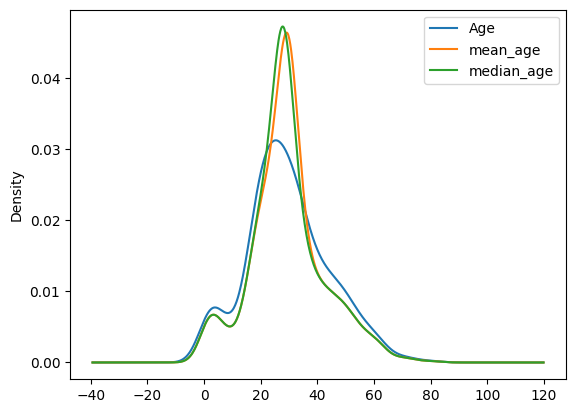

In [11]:
x_train['Age'].plot(kind='kde')
x_train['mean_age'].plot(kind='kde')
x_train['median_age'].plot(kind='kde')
plt.legend()

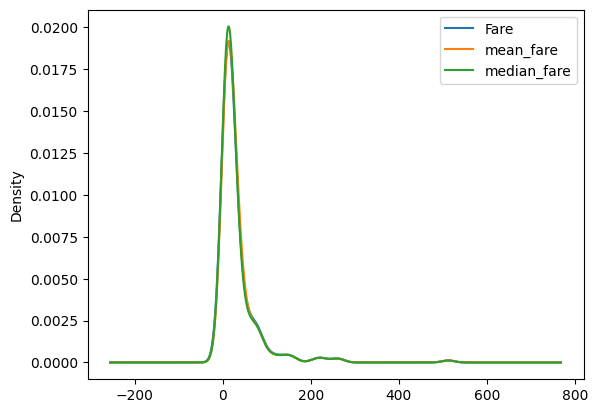

In [12]:
x_train['Fare'].plot(kind='kde')
x_train['mean_fare'].plot(kind='kde')
x_train['median_fare'].plot(kind='kde')
plt.legend()

<Axes: >

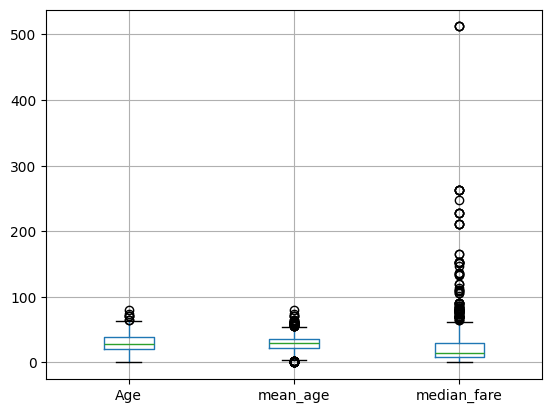

In [13]:
x_train[['Age','mean_age','median_fare']].boxplot()

<Axes: >

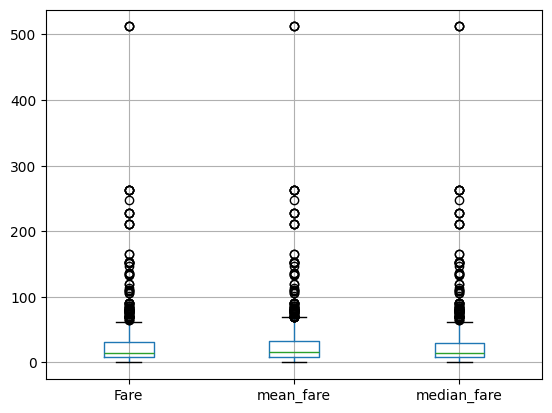

In [14]:
x_train[['Fare','mean_fare','median_fare']].boxplot()

# using sklearn

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
x_train.isnull().sum()

Age       140
Fare       36
Family      0
dtype: int64

In [17]:
trf=ColumnTransformer([
    ('imputer',SimpleImputer(strategy='mean'),['Age']),
    ('imputer2',SimpleImputer(strategy='median'),['Fare'])
],remainder='passthrough')

In [18]:
x_train2=trf.fit_transform(x_train)
x_test2=trf.transform(x_test)

In [19]:
x_train2

array([[ 45.5   ,  28.5   ,   0.    ],
       [ 23.    ,  13.    ,   0.    ],
       [ 32.    ,   7.925 ,   0.    ],
       ...,
       [ 41.    ,  14.4   ,   2.    ],
       [ 14.    , 120.    ,   3.    ],
       [ 21.    ,  77.2875,   1.    ]], shape=(712, 3))

In [34]:
x_train2=pd.DataFrame(x_train2)

In [21]:
x_train2.isnull().sum()

0    0
1    0
2    0
dtype: int64

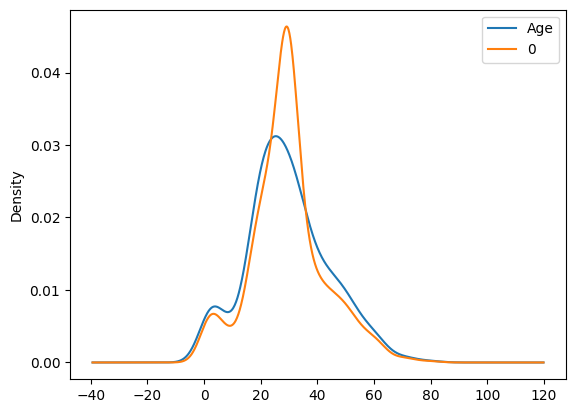

In [25]:
x_train['Age'].plot(kind='kde')
x_train2[0].plot(kind='kde')
plt.legend()

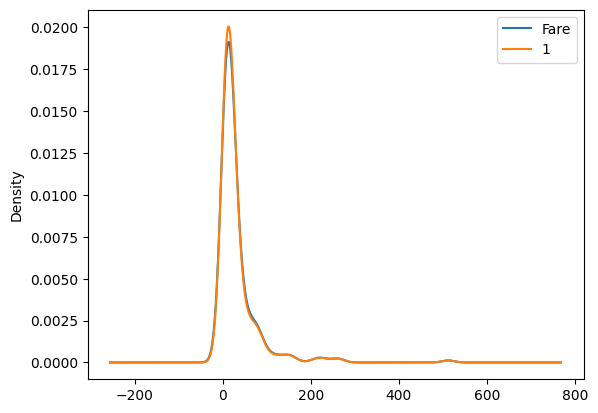

In [35]:
x_train['Fare'].plot(kind='kde')
x_train2[1].plot(kind='kde')
plt.legend()